# HyPyP Demonstration Notebook

Authors : Guillaume Dumas, Anaël Ayrolles, Florence Brun

Date : 2022-11-03

This notebook demonstrates the basic functionalities of the [HyPyP](https://github.com/ppsp-team/HyPyP/tree/master) library for hyperscanning EEG analysis. 

In this notebook we:
- **Load libraries** for core operations, data science, visualization, and EEG analysis (using MNE).
- **Set analysis parameters** such as frequency bands.
- **Load and preprocess data** (including ICA correction and autoreject) for two participants.
- **Perform analyses** such as power spectral density (PSD) estimation and connectivity analysis.
- **Run statistical tests** (parametric and non-parametric cluster-based permutations) on the computed data.
- **Visualize** the results with sensor maps and connectivity projections in both 2D and 3D.

The expected outputs are cleaned EEG epochs, PSD values, connectivity matrices, statistical test results, and visualizations that help interpret inter- and intra-brain connectivity.

#🧹 *****BrainHack Montreal 2026*****

Contributor: Joaquim Streicher

Date: 2026-01-28

## ***Main modifications***
I tried to merge the three following tutorials into one:

https://github.com/ppsp-team/HyPyP/blob/master/tutorial/getting_started.ipynb

https://github.com/ppsp-team/workshops/blob/practicalmeeg-2025/01_-_Short_Getting_Started.ipynb

https://github.com/Ramdam17/ConnectivityMetricsTutorials/tree/main

I also attempted to simplify steps to make it more straight-to-the-point for a total beginner.

Main changes include:
1. Using simulated synchronized data from Annemarie instead of imported non-hyperscanning data.
2. The preprocessing steps, including the ICA, has been simplified so that the user does not have to manually select anything.
3. I added some visualizatiopn steps and further explanations and ressources to make sure the user understands the main concepts, most notably: imaginary coherence, connectivity metrics, etc.

## To do from there:
1. Make sure simulated data, montage attribution, and preprocessing steps lead to tangible results for user.
2. Replace stats with UCLA workshop ones.
3. Explanations and instructions in greater detail.
4. Explain 9 possible metrics (2 sentences).

<details>

<summary>A. Ressources to understand hyperscanning</summary>

To understand what this code does on a higher, conceptual level, you can refer to the following references: 

1. Dumas, G., Nadel, J., Soussignan, R., Martinerie, J., & Garnero, L. (2010). Inter-brain synchronization during social interaction. PloS one, 5(8), e12166.
2. Dumas, G., Lachat, F., Martinerie, J., Nadel, J., & George, N. (2011). From social behaviour to brain synchronization: review and perspectives in hyperscanning. Irbm, 32(1), 48-53.

Moreover, information regarding the hypyp pipeline is avalaible here: 
Ayrolles, A., Brun, F., Chen, P., Djalovski, A., Beauxis, Y., Delorme, R., ... & Dumas, G. (2021). HyPyP: a Hyperscanning Python Pipeline for inter-brain connectivity analysis. Social Cognitive and Affective Neuroscience, 16(1-2), 72-83.

Please note that there are important steps prior to data analysis if one wants to perform hyperscanning analysis (experimental design, data acquisition). See:
Barraza, P., Dumas, G., Liu, H., Blanco-Gomez, G., van den Heuvel, M. I., Baart, M., & Pérez, A. (2019). Implementing EEG hyperscanning setups. MethodsX, 6, 428-436.

## Load libraries

### Core

In [1]:
from copy import copy
from collections import OrderedDict
import requests
import tempfile  # For creating temporary files

### Data science

In [2]:
import numpy as np # JS: maybe not necessary
import scipy

### Visualization

In [3]:
import matplotlib.pyplot as plt

### MNE

In [4]:
import mne
from mne.preprocessing import ICA
import mne_icalabel
from mne_icalabel import label_components

### HyPyP

In [5]:
from hypyp import prep 
from hypyp import analyses
from hypyp import stats
from hypyp import viz

## Simulate hyperscanning data

### We simlate EEG data for two imaginary participants.

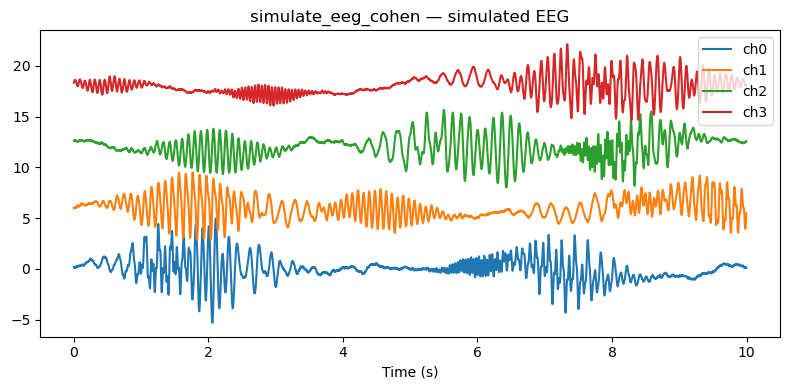

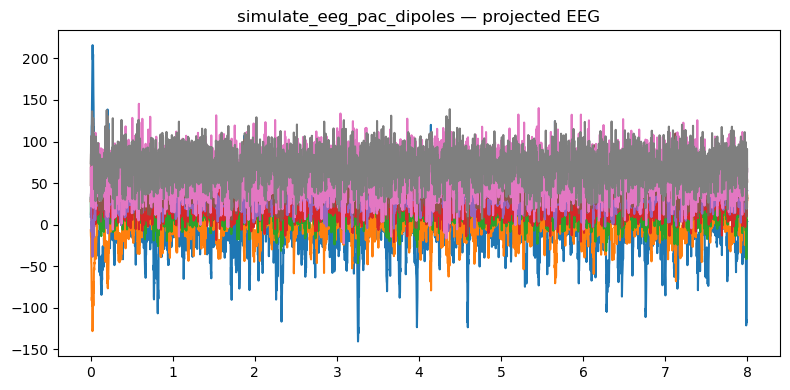

PAC channels: [1]


In [6]:
import os, sys
import matplotlib.pyplot as plt
import numpy as np

from utils_eeg_simulations import simulate_eeg_pac_dipoles, simulate_eeg_cohen, sinewave_multi_freq

# 1) Quick multichannel background + oscillations (no leadfield required)
eeg, time, freqs_psd, psd = simulate_eeg_cohen(duration=10, srate=500, n_channels=4, noise_level=0.5, seed=42)

plt.figure(figsize=(8,4))
for ch in range(eeg.shape[0]):
    plt.plot(time, eeg[ch] + ch*6, label=f'ch{ch}')
plt.xlabel('Time (s)')
plt.title('simulate_eeg_cohen — simulated EEG')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Simulate dipole->sensor projection (uses leadfield). If you don't have If_gain.mat, create a fake Gain.
mat_path = r'c:\path\to\If_gain.mat'  # adjust if you have a real file
if os.path.exists(mat_path):
    eeg2, time2, sources, mask, pac_ch = simulate_eeg_pac_dipoles(lf_mat=mat_path, srate=500, duration=8, seed=42)
else:
    # build a lightweight lf-like object compatible with lf_mat["lf"][0,0]["Gain"]
    fake_Gain = np.random.randn(32, 200)   # 32 channels x 200 sources
    lf_like = {"lf": np.array([[{"Gain": fake_Gain}]])}
    eeg2, time2, sources, mask, pac_ch = simulate_eeg_pac_dipoles(lf_mat=lf_like, srate=500, duration=8, seed=42)

plt.figure(figsize=(8,4))
for ch in range(min(8, eeg2.shape[0])):
    plt.plot(time2, eeg2[ch] + ch*10, label=f'ch{ch}')
plt.title('simulate_eeg_pac_dipoles — projected EEG')
plt.tight_layout()
plt.show()

print('PAC channels:', pac_ch)

### Here we do the same but ensure that the two simulated EEG signals are synchronized in some ways...

In [26]:
import os, sys
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils_eeg_simulations   # or utils_eeg_simulation
importlib.reload(utils_eeg_simulations)

from utils_eeg_simulations import (
    simulate_hyperscanning_eeg_shared_drive,
    load_leadfield_mat
)

lf_mat = load_leadfield_mat()

output = simulate_hyperscanning_eeg_shared_drive(
    lf_mat,
    srate=500,
    duration=30,
    theta_freq=6.0,
    gamma_freqs=(45.0, 55.0),
    dipoles=None,
    coupling_percent=0.5,
    coupling_strength_A=1.0,
    coupling_strength_B=1.0,
    coupling_delay_B_sec=0.2,
    noise_level_sources=1.0,
    white_level_sources=0.5,
    noise_level_eeg=0.5,
    corr_strength=0.95,
    orient=0,
    seed=42
)

output.keys()

dict_keys(['eeg_a', 'eeg_b', 'sources_a', 'sources_b', 'shared_drive', 'time'])

### ...and plot two channels.

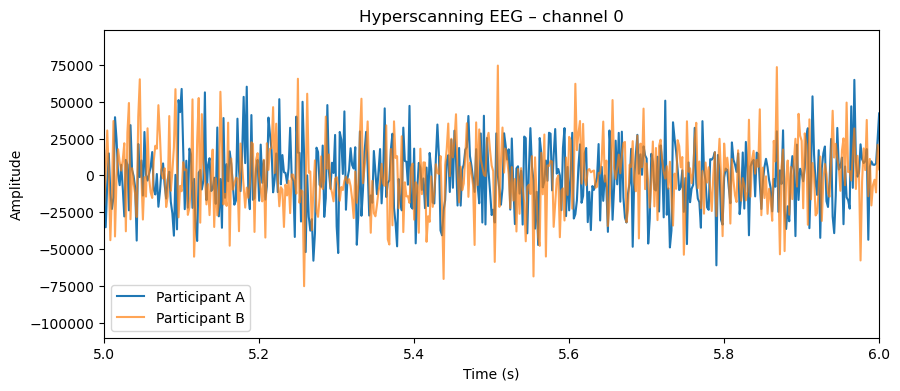

In [27]:
import matplotlib.pyplot as plt

channel = 0
time = output["time"]

plt.figure(figsize=(10, 4))
plt.plot(time, output["eeg_a"][channel], label="Participant A")
plt.plot(time, output["eeg_b"][channel], label="Participant B", alpha=0.7)
plt.xlim(5, 6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title(f"Hyperscanning EEG – channel {channel}")
plt.show()

### Make the data format usable as input for MNE functions.

In [28]:
import numpy as np
import mne

srate = 500
eeg_a = output["eeg_a"]
eeg_b = output["eeg_b"]

assert eeg_a.shape[0] == 64

# BioSemi 64 montage
montage = mne.channels.make_standard_montage("biosemi64")

ch_names = montage.ch_names  # exactly 64, correctly ordered

info = mne.create_info(ch_names=ch_names, sfreq=srate, ch_types="eeg")

raw_a = mne.io.RawArray(eeg_a, info, verbose=False)
raw_b = mne.io.RawArray(eeg_b, info, verbose=False)

raw_a.set_montage(montage)
raw_b.set_montage(montage)

raw_a, raw_b

(<RawArray | 64 x 15000 (30.0 s), ~7.4 MiB, data loaded>,
 <RawArray | 64 x 15000 (30.0 s), ~7.4 MiB, data loaded>)

### We also map channels on a sensor space.

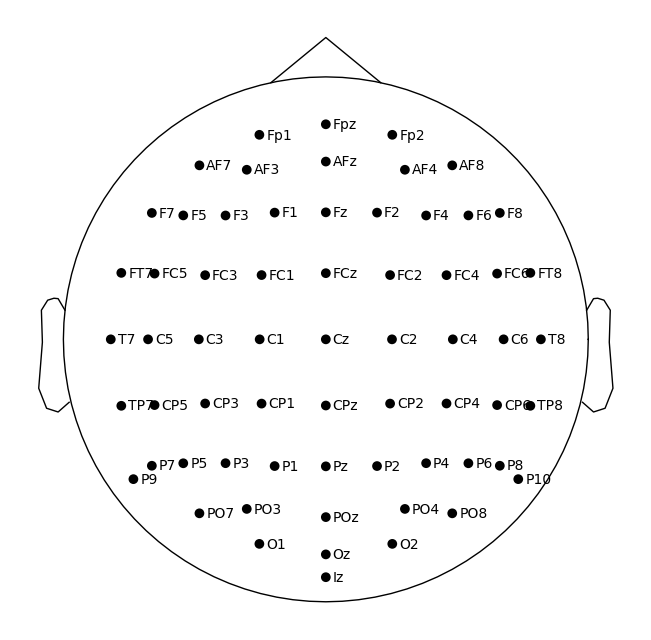

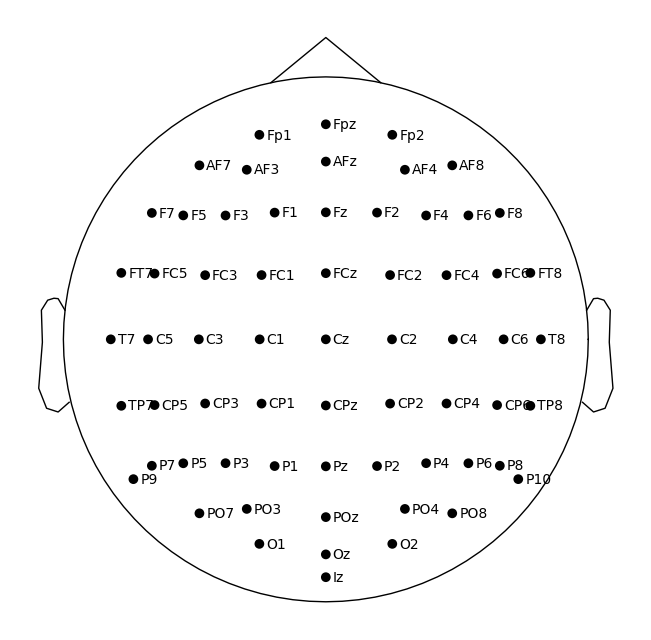

In [29]:
raw_a.plot_sensors(show_names=True)

## Preprocessing

In [30]:
# Paramètres de preprocessing
TARGET_SFREQ = 500
NOTCH_FREQS = [60, 120, 180]  # Hz (US power line + harmoniques, max < Nyquist 250Hz)
EPOCH_DURATION = 2.0  # secondes
ICA_N_COMPONENTS = 20
ICA_EXCLUDE_THRESHOLD = 0.5  # probabilité pour exclure une composante non-brain

sampling_rate = TARGET_SFREQ

### 1. Filters

In [31]:
raw_a.load_data()
raw_b.load_data()

# band-pass example
raw_a.filter(1., 100., fir_design="firwin", verbose=False)
raw_b.filter(1., 100., fir_design="firwin", verbose=False)

# notch example (line noise)
raw_a.notch_filter(freqs=[60])
raw_b.notch_filter(freqs=[60])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3301 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

<RawArray | 64 x 15000 (30.0 s), ~7.4 MiB, data loaded>

### 2. Average referencing

In [32]:
raw_a.set_eeg_reference("average")
raw_b.set_eeg_reference("average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawArray | 64 x 15000 (30.0 s), ~7.4 MiB, data loaded>

### 3. Epoching

In [33]:
epochs_a = mne.make_fixed_length_epochs(raw_a, duration=2.0, overlap=0.0, preload=True, verbose=False)
epochs_b = mne.make_fixed_length_epochs(raw_b, duration=2.0, overlap=0.0, preload=True, verbose=False)

print(epochs_a)
print(epochs_a.get_data().shape)  # (n_epochs, n_channels, n_times_epoch)

epochs = {}
epochs[1] = epochs_a
epochs[2] = epochs_b

<Epochs | 15 events (all good), 0 – 1.998 s (baseline off), ~7.4 MiB, data loaded,
 '1': 15>
(15, 64, 1000)


### 4. Pre-ICA auto-reject

Nettoyage des epochs avant l'entraînement ICA pour améliorer la qualité de la décomposition :

- **Interpolation** : Test de 1, 2, 4 ou 8 canaux à interpoler par epoch
- **Consensus** : Rejet si >30% des canaux sont mauvais dans un epoch
- **Objectif** : Fournir des données propres pour un meilleur fit ICA

For simplicity, epochs excluded in P1 is excluded in P2, and vice versa.

In [38]:
from autoreject import AutoReject
import numpy as np

sid1, sid2 = list(epochs.keys())[:2]

# Sanity check: same epoch grid
assert len(epochs_a) == len(epochs_b), "Different epoch count (not aligned)"
assert np.array_equal(epochs_a.events[:, 0], epochs_b.events[:, 0]), "Epochs not aligned in time"

ar1 = AutoReject(n_interpolate=[1,2,4,8,16,32],
                 consensus=[0.1,0.2,0.3],
                 random_state=42, n_jobs=-1, verbose=False)
ar2 = AutoReject(n_interpolate=[1,2,4,8,16,32],
                 consensus=[0.1,0.2,0.3],
                 random_state=42, n_jobs=-1, verbose=False)

ar1.fit(epochs_a)
ar2.fit(epochs_b)

bad1 = ar1.get_reject_log(epochs_a).bad_epochs
bad2 = ar2.get_reject_log(epochs_b).bad_epochs

# Option A: drop epochs rejected by either participant (recommended)
good = ~(bad1 | bad2)

epo1_joint = epochs_a[good]
epo2_joint = epochs_b[good]
print("Kept:", len(epo1_joint), len(epo2_joint))

epochs_clean_ica = {}
epochs_clean_ica[1] = epo1_joint
epochs_clean_ica[2] = epo2_joint

Kept: 14 14


### 5. ICA + ICLabel

Décomposition en composantes indépendantes et classification automatique :

- **Méthode** : Infomax étendu (20 composantes)
- **Classification** : ICLabel pour identifier les composantes (brain, eye, heart, muscle, etc.)
- **Exclusion** : Composantes non-brain avec probabilité > 50%
- **Application** : ICA appliqué directement sur les epochs filtrés

In [39]:
# ICA + ICLabel pour chaque sujet
ica_models = {}
epochs_ica = {}

for sid in epochs.keys():
    print(f"\n[{sid}] Fitting ICA...")
    
    # Créer et entraîner ICA
    ica = ICA(
        n_components=ICA_N_COMPONENTS,
        method='infomax',
        random_state=42,
        max_iter='auto',
        fit_params=dict(extended=True)
    )
    ica.fit(epochs_clean_ica[sid])
    
    # ICLabel classification
    ic_labels = label_components(epochs_clean_ica[sid], ica, method='iclabel')
    y_pred = np.array(ic_labels['y_pred_proba'])
    probabilities = y_pred.max(axis=1) if y_pred.ndim > 1 else y_pred
    
    # Identifier les composantes à exclure
    components_to_exclude = []
    label_counts = {}
    for i, (label, prob) in enumerate(zip(ic_labels['labels'], probabilities)):
        label_counts[label] = label_counts.get(label, 0) + 1
        if label != 'brain' and prob > ICA_EXCLUDE_THRESHOLD:
            components_to_exclude.append(i)
    
    ica.exclude = components_to_exclude
    ica_models[sid] = ica
    
    print(f"[{sid}] Labels: {label_counts}")
    print(f"[{sid}] Excluding {len(components_to_exclude)} components: {components_to_exclude}")
    
    # Appliquer ICA sur les epochs filtrés
    epochs_ica[sid] = ica.apply(epochs_clean_ica[sid].copy())
    print(f"[{sid}] ICA applied: {len(epochs_ica[sid])} epochs")


[1] Fitting ICA...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Computing Extended Infomax ICA
Fitting ICA took 12.1s.


C:\Users\Joaquim\AppData\Local\Temp\ipykernel_15688\3877014735.py:16: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (4.9e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 17
  ica.fit(epochs_clean_ica[sid])


[1] Labels: {'brain': 19, 'other': 1}
[1] Excluding 1 components: [19]
Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
[1] ICA applied: 14 epochs

[2] Fitting ICA...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Computing Extended Infomax ICA
Fitting ICA took 11.8s.


C:\Users\Joaquim\AppData\Local\Temp\ipykernel_15688\3877014735.py:16: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (5e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 18
  ica.fit(epochs_clean_ica[sid])


[2] Labels: {'brain': 20}
[2] Excluding 0 components: []
Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 64 PCA components
[2] ICA applied: 14 epochs


## Second AutoReject (post-ICA)

Nettoyage final après suppression des artefacts ICA :

- **Objectif** : Éliminer les epochs restants avec des artefacts résiduels
- **Paramètres** : Identiques au premier AutoReject (consensus 30%)
- **Résultat** : Epochs prêts pour l'analyse hyperscanning

In [45]:
from autoreject import AutoReject
import numpy as np

# --- participants ---
sids = list(epochs_ica.keys())
assert len(sids) == 2, f"Expected exactly 2 participants, got: {sids}"
sid1, sid2 = sids[0], sids[1]

e1 = epochs_ica[sid1]
e2 = epochs_ica[sid2]

# --- (A) Align epochs by event onsets if needed (safe) ---
on1 = e1.events[:, 0]
on2 = e2.events[:, 0]
common = np.intersect1d(on1, on2)

if len(common) == 0:
    raise RuntimeError("No common epoch onsets between participants. Something upstream epoched/dropped differently.")

idx1 = np.where(np.isin(on1, common))[0]
idx2 = np.where(np.isin(on2, common))[0]

e1 = e1[idx1]
e2 = e2[idx2]

# Now epoch grid should match 1-to-1
assert len(e1) == len(e2), "Still mismatched after alignment"
assert np.array_equal(e1.events[:, 0], e2.events[:, 0]), "Epochs still not aligned after alignment"

# --- (B) Run AutoReject separately to compute bad masks ---
reject_logs = {}
epochs_interp_tmp = {}  # optional: interpolation only

for sid, epo in [(sid1, e1), (sid2, e2)]:
    print(f"\n[{sid}] AutoReject final (post-ICA)...")

    ar = AutoReject(
        n_interpolate=[1, 2, 4, 8],
        consensus=[0.3],
        random_state=42,
        n_jobs=-1,
        verbose=False,
    )

    ar.fit(epo)

    reject_log = ar.get_reject_log(epo)
    reject_logs[sid] = reject_log.bad_epochs.copy()

    # optional: apply interpolation (does not enforce joint dropping by itself)
    epochs_interp_tmp[sid] = ar.transform(epo)

    n_rej = int(reject_logs[sid].sum())
    print(f"[{sid}] would reject {n_rej} / {len(epo)} epochs alone")

# --- (C) Joint rejection mask (reject if either is bad) ---
bad1 = reject_logs[sid1]
bad2 = reject_logs[sid2]
good = ~(bad1 | bad2)

print(f"\nJointly keeping {good.sum()} / {len(good)} epochs")

# --- (D) Apply SAME epoch selection to both participants ---
epochs_clean_final = {
    sid1: e1[good],
    sid2: e2[good],
}

print(f"[{sid1}] final: {len(epochs_clean_final[sid1])}")
print(f"[{sid2}] final: {len(epochs_clean_final[sid2])}")

# Final alignment guarantee
assert np.array_equal(
    epochs_clean_final[sid1].events[:, 0],
    epochs_clean_final[sid2].events[:, 0]
), "Final epochs not aligned (should not happen)"


[1] AutoReject final (post-ICA)...
[1] would reject 0 / 14 epochs alone

[2] AutoReject final (post-ICA)...
[2] would reject 0 / 14 epochs alone

Jointly keeping 14 / 14 epochs
[1] final: 14
[2] final: 14


## Setting Analysis Parameters

We define the frequency bands used in the study. Here we use two bands within the Alpha range. We also use an `OrderedDict` to preserve the order of the bands.

# ***JS suggestions:***
- Could explain more why selected bands
- Unclear why OrderedDict.

In [46]:
# Define frequency bands as a dictionary
freq_bands = {
    'Alpha-Low': [7.5, 11],
    'Alpha-High': [11.5, 13]
}

# Convert to an OrderedDict to keep the defined order
freq_bands = OrderedDict(freq_bands)
print('Frequency bands:', freq_bands)

Frequency bands: OrderedDict([('Alpha-Low', [7.5, 11]), ('Alpha-High', [11.5, 13])])


In [47]:
# Assign cleaned epochs to individual participant variables
preproc_S1 = epochs_clean_final[1]
preproc_S2 = epochs_clean_final[2]
print('Preprocessed epochs for both participants are ready.')

Preprocessed epochs for both participants are ready.


## Analysing Data: Welch Power Spectral Density (PSD)

Here we compute the PSD for each participant in the Alpha-Low band using the HyPyP `analyses.pow` function. The PSD values are averaged across epochs.

In [48]:
# Compute PSD for participant 1 in the Alpha-Low band
psd1 = analyses.pow(
    preproc_S1,
    fmin=7.5,
    fmax=11,
    n_fft=1000,
    n_per_seg=1000,
    epochs_average=True
)

# Compute PSD for participant 2 in the Alpha-Low band
psd2 = analyses.pow(
    preproc_S2,
    fmin=7.5,
    fmax=11,
    n_fft=1000,
    n_per_seg=1000,
    epochs_average=True
)

# Combine PSD data into a single array
data_psd = np.array([psd1.psd, psd2.psd])
print('PSD analysis completed.')

Effective window size : 2.000 (s)
Effective window size : 2.000 (s)
PSD analysis completed.


## Connectivity Analysis

In this section we compute brain connectivity metrics. 

1. We first compute the analytic signal per frequency band using `analyses.compute_freq_bands`.
2. Then, we compute connectivity (using the 'ccorr' mode) and average across epochs.
3. We slice the resulting connectivity matrices to extract both inter-brain (between participants) and intra-brain (within a participant) connectivity values.
4. A Z-score normalization is performed for illustration purposes.

In [49]:
# Prepare data for connectivity analysis (combine both participants)
data_inter = np.array([preproc_S1, preproc_S2])
result_intra = []

# Compute the analytic signal in each frequency band
complex_signal = analyses.compute_freq_bands(
    data_inter,
    sampling_rate,
    freq_bands,
    filter_length=int(sampling_rate),  # Adjust filter length based on sampling rate
    l_trans_bandwidth=5.0,  # Reduced transition bandwidth
    h_trans_bandwidth=5.0
)

# Compute connectivity using cross-correlation ('ccorr') and average across epochs
result = analyses.compute_sync(complex_signal, mode='ccorr', epochs_average=True)

# Determine the number of channels
n_ch = len(epo1.info['ch_names'])

# Slice the connectivity matrix to get inter-brain connectivity in the Alpha-Low band
alpha_low, alpha_high = result[:, 0:n_ch, n_ch:2*n_ch]

# For further analysis, choose the Alpha-Low band values
values = alpha_low

# Compute a Z-score normalized connectivity matrix
C = (values - np.mean(values[:])) / np.std(values[:])

# Process intra-brain connectivity for each participant
for i in [0, 1]:
    # Slice intra-brain connectivity matrix
    alpha_low, alpha_high = result[:, (i * n_ch):((i + 1) * n_ch), (i * n_ch): ((i + 1) * n_ch)]
    values_intra = alpha_low
    
    # Remove self-connections
    values_intra -= np.diag(np.diag(values_intra))
    
    # Compute Z-score normalization for intra connectivity
    C_intra = (values_intra - np.mean(values_intra[:])) / np.std(values_intra[:])
    result_intra.append(C_intra)

print('Connectivity analysis completed.')

Connectivity analysis completed.


## Statistical Analyses

We perform several statistical tests on the computed PSD and connectivity data. These include:

- A parametric permutation t-test on the PSD values.
- Non-parametric cluster-based permutation tests for both PSD and connectivity data.

#### 1/ MNE test without any correction
This function takes samples (observations) by number of tests (variables i.e. channels), thus PSD values are averaged in the frequency dimension


In [50]:
# Compute mean PSD values for each channel across epochs for both participants
psd1_mean = np.mean(psd1.psd, axis=1)
psd2_mean = np.mean(psd2.psd, axis=1)

# Combine the means into a single array for the t-test
X = np.array([psd1_mean, psd2_mean])

# Perform permutation t-test (using MNE) without correction for multiple comparisons
T_obs, p_values, H0 = mne.stats.permutation_t_test(
    X=X,
    n_permutations=5000,
    tail=0,
    n_jobs=1
)
print('Permutation t-test completed.')

# Alternatively, compute statistical conditions using HyPyP's statsCond function
statsCondTuple = stats.statsCond(
    data=data_psd,
    epochs=preproc_S1,
    n_permutations=5000,
    alpha=0.05
)
print('Statistical condition tuple computed.')

Permuting 1 times (exact test)...
Permutation t-test completed.
Permuting 1 times (exact test)...
Statistical condition tuple computed.


### Non-parametric Cluster-Based Permutations

Here, we create a priori connectivity matrices based on sensor positions and then perform cluster-based permutation tests. 

In this example, we create two fake groups (by replicating each participant's PSD data with added noise) and run the permutation test.

In [51]:
# Create connectivity matrix for a priori sensor connectivity using participant 1's sensor layout
con_matrixTuple = stats.con_matrix(preproc_S1, freqs_mean=psd1.freq_list)
ch_con_freq = con_matrixTuple.ch_con_freq

# Create two fake groups by replicating the PSD data and adding a small noise
noise_level = 1e-6  # Small noise to break exact duplicates
data_group = [
    np.array([psd1.psd + np.random.normal(0, noise_level, psd1.psd.shape) for _ in range(3)]),
    np.array([psd2.psd + np.random.normal(0, noise_level, psd2.psd.shape) for _ in range(3)])
]

# Perform non-parametric cluster-based permutation test on the fake groups
statscondCluster = stats.statscondCluster(
    data=data_group,
    freqs_mean=psd1.freq_list,
    ch_con_freq=scipy.sparse.bsr_matrix(ch_con_freq),
    tail=1,
    n_permutations=5000,
    alpha=0.05
)
print('Cluster-based permutation test for PSD completed.')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 64
Using a threshold of 7.708647
stat_fun(H1): min=-4471481495421488.0 max=inf
Running initial clustering …
Found 1 cluster


c:\Users\Joaquim\miniconda3\envs\hypyp-env\Lib\site-packages\mne\stats\parametric.py:171: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
c:\Users\Joaquim\miniconda3\envs\hypyp-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]c:\Users\Joaquim\miniconda3\envs\hypyp-env\Lib\site-packages\mne\stats\parametric.py:171: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
100%|██████████| Permuting : 4999/4999 [00:00<00:00, 7134.14it/s]

Cluster-based permutation test for PSD completed.


### Comparing Intra-Brain Connectivity Between Participants

We now compute a connectivity matrix for intra-brain connectivity and perform a cluster-based permutation test comparing the two participants. 

Again, we generate two fake groups by replicating each participant’s intra-brain connectivity data and adding noise.

Note that for connectivity, values are computed for every integer in the frequency bin from fmin to fmax, freqs_mean=np.arange(fmin, fmax) whereas in PSD it depends on the n_fft parameter psd.freq_list

For CSD, values are averaged across each frequencies so you do not need to take frequency into account to correct clusters

In [52]:
# Create connectivity matrix for intra-brain connectivity
con_matrixTuple = stats.con_matrix(
    epochs=preproc_S1,
    freqs_mean=np.arange(7.5, 11),
    draw=False
)

ch_con = con_matrixTuple.ch_con

# Create fake groups for intra-brain connectivity analysis
Alpha_Low = [
    np.array([
        result_intra[0] + np.random.normal(0, noise_level, result_intra[0].shape),
        result_intra[0] + np.random.normal(0, noise_level, result_intra[0].shape)
    ]),
    np.array([
        result_intra[1] + np.random.normal(0, noise_level, result_intra[1].shape),
        result_intra[1] + np.random.normal(0, noise_level, result_intra[1].shape)
    ])
]

# Run cluster-based permutation test for intra-brain connectivity
statscondCluster_intra = stats.statscondCluster(
    data=Alpha_Low,
    freqs_mean=np.arange(7.5, 11),
    ch_con_freq=scipy.sparse.bsr_matrix(ch_con),
    tail=1,
    n_permutations=5000,
    alpha=0.05
)
print('Intra-brain connectivity cluster test completed.')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 64
Using a threshold of 18.512821
stat_fun(H1): min=7787.798666419707 max=222876952364524.0
Running initial clustering …
Found 1 cluster


100%|██████████| Permuting : 4999/4999 [03:15<00:00,   25.51it/s]

Intra-brain connectivity cluster test completed.


### Comparing Inter-Brain Connectivity to Random Signal

Finally, we compare inter-brain connectivity values to a random signal. In this case, no a priori connectivity matrix is used between the two participants. We again create fake groups and run the permutation test.

In [53]:
# Create fake groups for inter-brain connectivity analysis
data = [
    np.array([
        values, 
        values + np.random.normal(0, 1e-6, values.shape)
    ]), 
    np.array([
        result_intra[0], 
        result_intra[0] + np.random.normal(0, 1e-6, result_intra[0].shape)
    ])
]

print(len(data[0][0]), len(data[0][1]), len(data[1][0]), len(data[1][1]))


# Run cluster-based permutation test for inter-brain connectivity without connectivity priors
statscondCluster = stats.statscondCluster(
    data=data,
    freqs_mean=np.linspace(7.5, 11, data[0].shape[-1]),
    ch_con_freq=None,
    tail=0,
    n_permutations=5000,
    alpha=0.05
)
print('Inter-brain connectivity cluster test completed.')

64 64 64 64
stat_fun(H1): min=571817060.8496878 max=inf
Running initial clustering …
Found 1 cluster


100%|██████████| Permuting : 4999/4999 [00:01<00:00, 4226.46it/s]


Inter-brain connectivity cluster test completed.


## Visualization

In this final section, we visualize the statistical results and connectivity maps. We use HyPyP visualization functions to:

- Plot sensor-level T-values for all sensors and for only significant sensors.
- Visualize inter-brain connectivity on 2D and 3D head models.
- Visualize intra-brain connectivity for each participant in both 2D and 3D.

Note: We manually specify bad channels for visualization purposes.

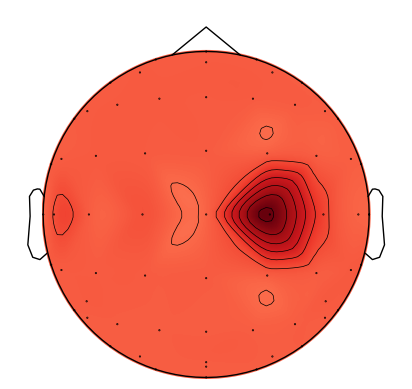

Sensor-level T-values plotted.


In [54]:
# Plot sensor-level T-values using the t-statistics computed earlier
viz.plot_significant_sensors(
    T_obs_plot=statsCondTuple.T_obs,
    epochs=preproc_S1
)
print('Sensor-level T-values plotted.')

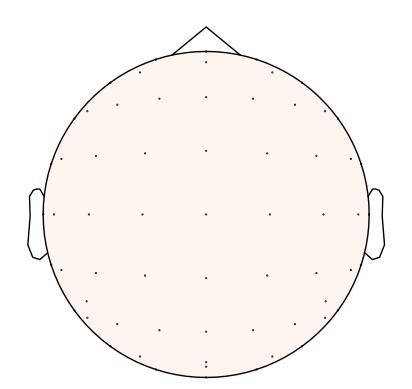

Significant sensors T-values plotted.


In [55]:
# Plot only the T-values for sensors that are statistically significant
viz.plot_significant_sensors(
    T_obs_plot=statsCondTuple.T_obs_plot,
    epochs=preproc_S1
)
print('Significant sensors T-values plotted.')

### Visulization of inter-brain links projected
on either 2D or 3D head models

It can be applied to Cohen’s D (C as done here) or statistical values (statscondCluster.F_obs or F_obs_plot) of inter-individual brain connectivity

### Visualisation of brain connectivity in 2D and 3D
Defining head model and adding sensors

Warning, threshold='auto' must be used carefully, it is calculated specifically for the dyad, and therefore does not allow comparability between different dyads.

#### Visualization of inter-brain connectivity in 2D

Inter-brain Hilbert-based connectivity

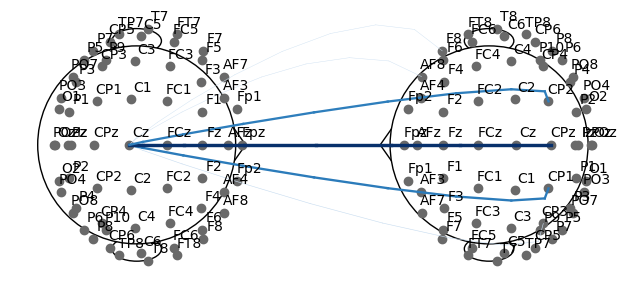

<Axes: >

In [58]:
viz.viz_2D_topomap_inter(epochs_a, epochs_b, C, threshold='auto', steps=10, lab=True)

#### Visualization of inter-brain connectivity in 3D

Inter-brain Hilbert-based connectivity


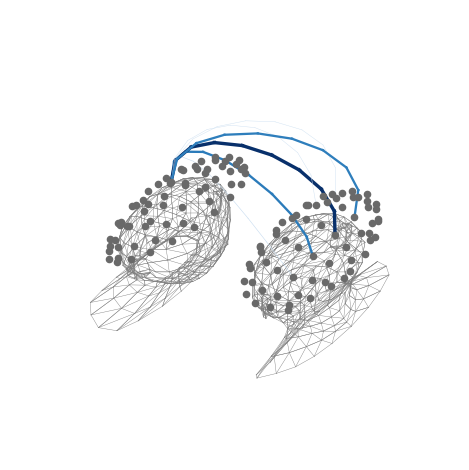

3D inter-brain connectivity visualization completed.


In [59]:
viz.viz_3D_inter(epochs_a, epochs_b, C, threshold='auto', steps=10, lab=False)
print('3D inter-brain connectivity visualization completed.')